significant trials, significant GT \n
plot trials based on significance or sleep state

In [1]:
import os
import numpy as np
import mne
import imageio
import h5py
# import scipy.fftpack
import matplotlib
import pywt
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
# from scipy import signal
from matplotlib.colors import ListedColormap
import time
import seaborn as sns

# import scipy.io as sio
# from scipy.integrate import simps
import pandas as pd
# from scipy import fft
import matplotlib.mlab as mlab
import sys
import matplotlib as mpl
sys.path.append('T:\EL_experiment\Codes\CCEP_human\Python_Analysis\py_functions')
import NMF_funcs as NMFf
import significant_connections as SCF
from scipy.stats import norm
import LL_funcs as LLf
from scipy.stats import norm
from tkinter import filedialog
from tkinter import *
import ntpath
import supp_sleep_CCEP_figures as fig_sleep
root = Tk()
root.withdraw()
import math
import scipy
from scipy import signal
import pylab
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
import platform
from glob import glob
from scipy.io import savemat
import scipy.cluster.hierarchy as spc
from scipy.spatial import distance
from sklearn.cluster import KMeans
import h5py
import basic_func as bf
from scipy.integrate import simps
from numpy import trapz
#import IO_func as IOF
#import BM_func as BMf
import tqdm
from matplotlib.patches import Rectangle
from pathlib import Path
sub_path  ='X:\\4 e-Lab\\' # y:\\eLab
import BM_plots as BMp
import freq_funcs as ff
import CCEP_plot
import supp_CCEP_figures as CCEP_supp
import random
import math
from sklearn.metrics import cohen_kappa_score, jaccard_score, accuracy_score
dist_groups = np.array([[0, 30], [30, 60], [60, 120]])
dist_labels = ['local (<30 mm)', 'short (<60mm)', 'long']
Fs = 500
dur = np.zeros((1, 2), dtype=np.int32)
t0 = 1
dur[0, 0] = -t0
dur[0, 1] = 3

folder = 'BrainMapping'
# dur[0,:]       = np.int32(np.sum(abs(dur)))
x_ax = np.arange(dur[0, 0], dur[0, 1], (1 / Fs))
color_elab = np.zeros((3, 3))
color_elab[0, :] = np.array([31, 78, 121]) / 255
color_elab[1, :] = np.array([189, 215, 238]) / 255
color_elab[2, :] = np.array([0.256, 0.574, 0.431])
cwd = os.getcwd()
color_sleep = ['#808080', '#145da0', '#ff1919']
label_sleep = ['Wake', 'NREM', 'REM']
color_dist = ['0000FF','#0076C4','#00DD91']
import CCEP_func

In [2]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols 
from scipy import stats

In [3]:
from scipy.signal import savgol_filter, find_peaks, peak_prominences

In [4]:
cond_folder = 'CR'
path_gen_base = sub_path + '\Patients'

In [5]:
CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
tab_region = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='plot')
tab_region = tab_region.sort_values('Order').reset_index(drop=True)
regions_all = tab_region.Area.values
region_col = tab_region.color.values

CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
all_region = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='atlas')

In [6]:
plt.rcParams.update({
            'font.family': 'arial',
            'font.size': 12,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 9,
            'svg.fonttype': 'none',
            'font.size': 10,
            'axes.titlesize': 10,
            'axes.labelsize': 8,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 9,
            'figure.titlesize': 10
        })

# General 

In [7]:
import load_summary as ls

In [8]:
subjs = ["EL010", "EL011","EL012","EL013", "EL014", "EL015", "EL016", "EL019", "EL020", "EL021",
         "EL022", "EL024", "EL026", "EL027", "EL028"]

con_all = ls.get_connections(subjs, sub_path)
con_all = con_all[(con_all.Num_sig_trial >10)&(con_all.True_peak == 1)].reset_index(drop=True)
con_all['Con_ID'] = con_all.groupby(['Subj', 'Stim', 'Chan']).ngroup()

In [9]:
col_keep = ['Stim', 'Chan', 'StimR', 'ChanR', 'd', 'Sig', 'delay', 'peak_latency', 'H']

In [10]:
data_plot = con_all[col_keep].reset_index(drop=True)

In [ ]:
# Create linear regression object
regression = LinearRegression()
regression.fit(X, y)

# Make predictions using the regression object
y_pred = regression.predict(X)

plt.figure(figsize=(4,4))
# Scatterplot of the data
plt.scatter(X, y, color='k',s = 2, label='Data', alpha =.7)

# Line of best fit
plt.plot(X, y_pred, color='red', linewidth=2, label='Fit')

In [21]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

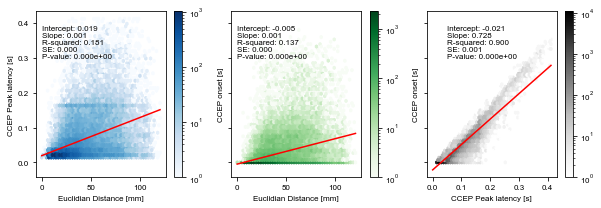

In [55]:
# possible labels
x_data = 'delay'
x_label = 'CCEP onset [s]'

x_data = 'd'
x_label = 'Euclidian Distance [mm]s]'

y_data = 'peak_latency'
y_label = 'CCEP Peak latency [s]'


fig, axs = plt.subplots(1,3, figsize=(8.5,3), sharey=True)
# create 1x3 subplot figure
i = 0
for y_data, y_label, x_data, x_label, cmap in zip(['peak_latency','delay','delay'],['CCEP Peak latency [s]','CCEP onset [s]','CCEP onset [s]'],['d','d','peak_latency'],['Euclidian Distance [mm]','Euclidian Distance [mm]','CCEP Peak latency [s]'],['Blues','Greens','Greys']):
    ax = axs[i]
    # color first blue, then green than black
    # ionstead of scatterplot make hexbin
    x = data_plot[x_data]
    y = data_plot[y_data]
    hb = ax.hexbin(x,y, cmap =cmap,gridsize = 50, bins ='log')
    cb = fig.colorbar(hb, ax=ax)
    # add linear regression
    # Calculate the linear regression parameters and R^2
    slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)

    # Add R^2 to the plot
    # Add regression details to plot
    text_str = f'Intercept: {intercept:.3f}\nSlope: {slope:.3f}\nR-squared: {r_value**2:.3f}\nSE: {std_err:.3f}\nP-value: {p_value:.3e}'
    ax.text(0.05, 0.3, text_str, fontsize = 8)

    x_ax_reg = np.linspace(0, np.nanmax(x), 2)

    y_ax_reg = intercept + slope*x_ax_reg
    ax.plot(x_ax_reg, y_ax_reg, color = 'r')

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    i = i+1
plt.tight_layout()
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\latency_onset_distance.svg'
plt.savefig(file)

## bRAIN REGIONS

### Heatmap

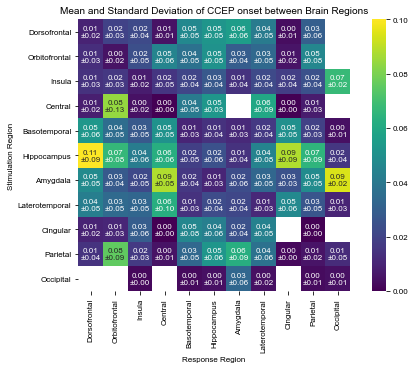

In [11]:
metric = 'delay'
metric_label = 'N1 latency'
z_max = 0.15
if metric == 'delay':
    metric_label = 'CCEP onset'
    z_max = 0.1
grouped_data = data_plot.groupby(['StimR', 'ChanR'])[metric].agg(['mean', 'std'])

# 2. Create a Data Matrix
data_matrix = pd.DataFrame(index=regions_all, columns=regions_all)
for (stim, chan), values in grouped_data.iterrows():
    if stim in regions_all and chan in regions_all:
        data_matrix.at[stim, chan] = f"{values['mean']:.2f}\n±{values['std']:.2f}"

# Reorder data matrix and annotation matrix
reordered_data = grouped_data['mean'].unstack().reindex(index=regions_all, columns=regions_all)
annot_matrix = data_matrix.reindex(index=regions_all, columns=regions_all)

# 3. Plot the Heatmap with ordered x-ticks and colorbar limit
fig = plt.figure(figsize=(8, 5))
fig.patch.set_facecolor('xkcd:white')
ax = sns.heatmap(reordered_data, annot=annot_matrix,annot_kws={"fontsize":8}, fmt='', cmap='viridis', cbar=True, vmax=z_max)

# Ensuring the heatmap is square
ax.set_aspect('equal', 'box')
# 4. Add titles and labels
plt.title('Mean and Standard Deviation of ' +metric_label +' between Brain Regions')
plt.xlabel('Response Region')
plt.ylabel('Stimulation Region')
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\'+metric+'_region.svg'
plt.savefig(file)
plt.show()


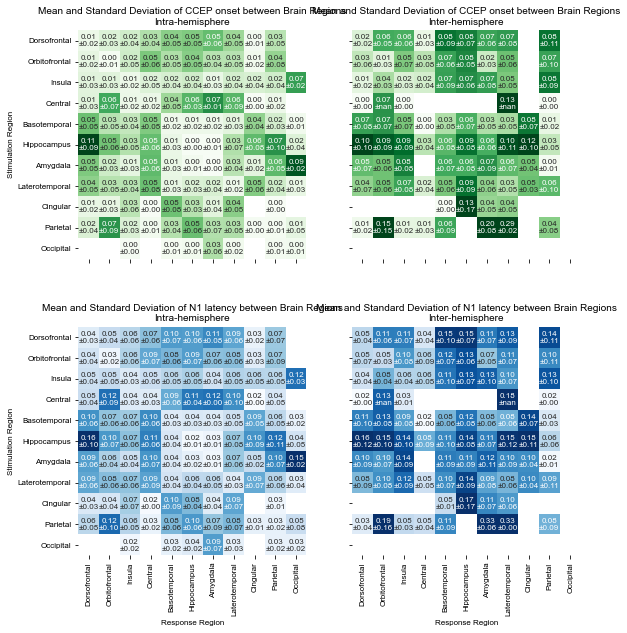

In [56]:
# Setup the figure for 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(9, 10), sharex=True, sharey=True, gridspec_kw={'wspace': 0.2, 'hspace': 0.2})

# Iterate over the grid to plot
for i, metric in enumerate(['delay', 'peak_latency']):
    for h in range(2):
        # Setup depending on metric
        metric_label = 'N1 latency' if metric == 'peak_latency' else 'CCEP onset'
        z_max = 0.1 if metric == 'delay' else 0.15
        cmap = 'Greens' if metric == 'delay' else 'Blues'
        
        # Filter and group data according to 'H' and current metric
        grouped_data = data_plot[data_plot.H == h].groupby(['StimR', 'ChanR'])[metric].agg(['mean', 'std'])
        
        # Create data matrix
        data_matrix = pd.DataFrame(index=regions_all, columns=regions_all)
        for (stim, chan), values in grouped_data.iterrows():
            if stim in regions_all and chan in regions_all:
                data_matrix.at[stim, chan] = f"{values['mean']:.2f}\n±{values['std']:.2f}"
        
        # Reorder data and annotation matrix
        reordered_data = grouped_data['mean'].unstack().reindex(index=regions_all, columns=regions_all)
        annot_matrix = data_matrix.reindex(index=regions_all, columns=regions_all)

        # Plot heatmap
        #ax = sns.heatmap(reordered_data, ax=axs[i, h], annot=annot_matrix, annot_kws={"fontsize":8}, fmt='',
        #                 cmap=cmap, cbar=i == 1 and h == 1, cbar_ax=None if i == 0 or h == 0 else axs[:, -1], vmax=z_max)
        
        ax = sns.heatmap(reordered_data, ax=axs[i, h], annot=annot_matrix, annot_kws={"fontsize":8}, fmt='',
                         cmap=cmap, cbar= 0, vmax=z_max)
        
        # Set aspect and add titles/labels
        ax.set_aspect('equal', 'box')
        hemisphere_label = 'Intra-hemisphere' if h == 0 else 'Inter-hemisphere'
        ax.set_title(f'Mean and Standard Deviation of {metric_label} between Brain Regions\n{hemisphere_label}')

# Set common labels
for ax in axs.flat:
    ax.set(xlabel='Response Region', ylabel='Stimulation Region')
    
# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\onset_latency_region_all.svg'
plt.savefig(file)
plt.show()

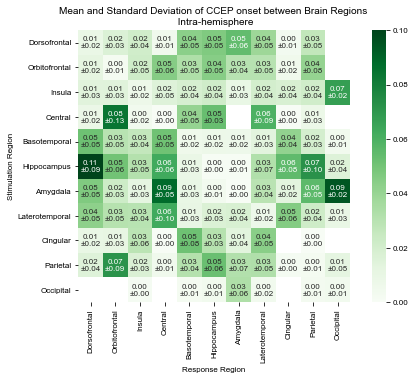

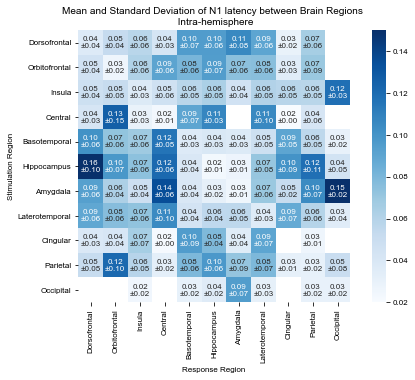

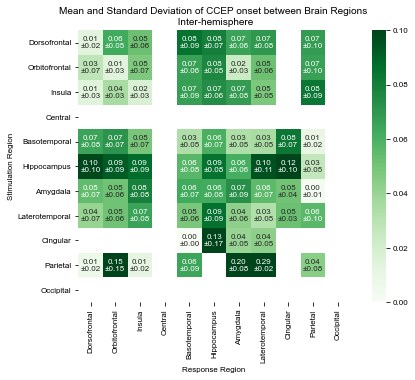

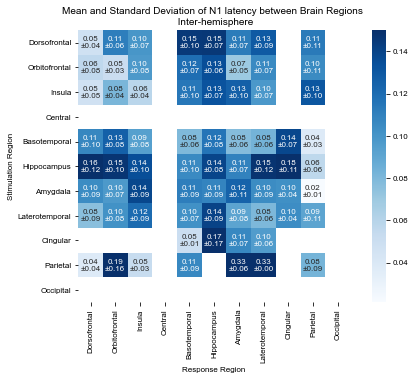

In [379]:
h = 0
for h in range(2):
    for metric in ['delay', 'peak_latency']: #metric = 'delay'
        metric_label = 'N1 latency'
        z_max = 0.15
        cmap = 'Blues'
        if metric == 'delay':
            metric_label = 'CCEP onset'
            z_max = 0.1
            cmap = 'Greens'
        grouped_data = data_plot[data_plot.H==h].groupby(['StimR', 'ChanR'])[metric].agg(['mean', 'std'])

        # 2. Create a Data Matrix
        data_matrix = pd.DataFrame(index=regions_all, columns=regions_all)
        for (stim, chan), values in grouped_data.iterrows():
            if stim in regions_all and chan in regions_all:
                data_matrix.at[stim, chan] = f"{values['mean']:.2f}\n±{values['std']:.2f}"

        # Reorder data matrix and annotation matrix
        reordered_data = grouped_data['mean'].unstack().reindex(index=regions_all, columns=regions_all)
        annot_matrix = data_matrix.reindex(index=regions_all, columns=regions_all)

        # 3. Plot the Heatmap with ordered x-ticks and colorbar limit
        fig = plt.figure(figsize=(8, 5))
        fig.patch.set_facecolor('xkcd:white')
        ax = sns.heatmap(reordered_data, annot=annot_matrix,annot_kws={"fontsize":8}, fmt='', cmap=cmap, cbar=True, vmax=z_max)

        # Ensuring the heatmap is square
        ax.set_aspect('equal', 'box')
        # 4. Add titles and labels
        plt.title('Mean and Standard Deviation of ' +metric_label +' between Brain Regions')
        plt.xlabel('Response Region')
        plt.ylabel('Stimulation Region')
        if h==0:
            file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\'+metric+'_region_intraH.svg'
            plt.title('Mean and Standard Deviation of ' +metric_label +' between Brain Regions \n Intra-hemisphere')
        else:
            file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\'+metric+'_region_interH.svg'
            plt.title('Mean and Standard Deviation of ' +metric_label +' between Brain Regions \n Inter-hemisphere')
        plt.savefig(file)
        plt.show()


### Histogram

C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\ipykernel_launcher.py:10: RuntimeWarning: Mean of empty slice
  # Remove the CWD from sys.path while we load stuff.


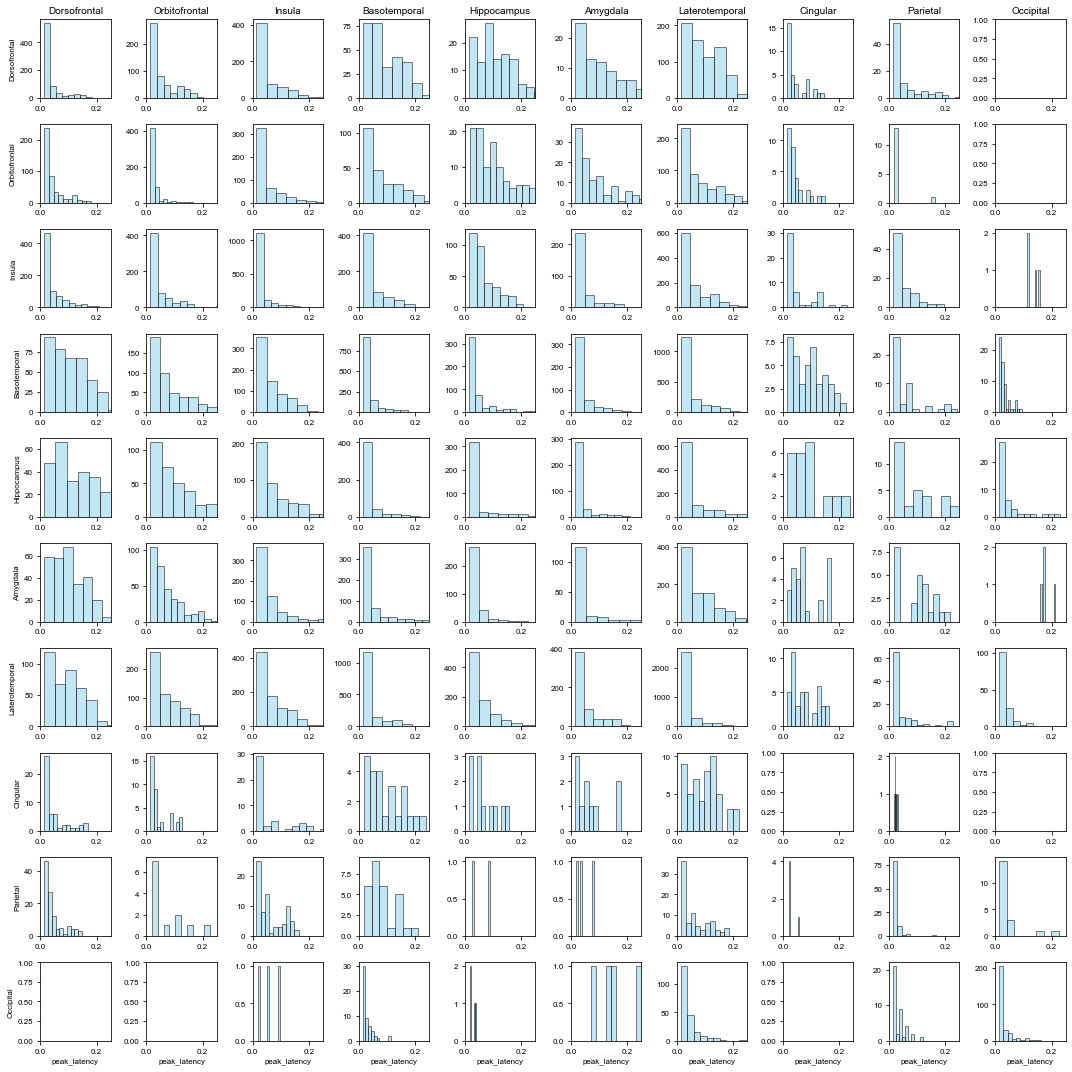

In [263]:
metric = 'peak_latency'
# Create a grid of subplots
fig, axes = plt.subplots(len(regions_all), len(regions_all), figsize=(15, 15))
fig.patch.set_facecolor('xkcd:white')
# Iterate over each subplot
for i, stim_region in enumerate(regions_all):
    for j, chan_region in enumerate(regions_all):
        # Filter the DataFrame for the current pair of regions
        subset = data_plot[(data_plot['StimR'] == stim_region) & (data_plot['ChanR'] == chan_region)][metric].values
        if np.nanmean(subset)>0:
            # Plot histogram in the subplot
            axes[i, j].hist(subset, color='skyblue', edgecolor='black', alpha = 0.5)
            # subset.plot.density(color='r', alpha=1, ax=axes[i, j])
            # Optional: Set title or labels for each subplot if needed
            
        if i == len(regions_all)-1:
            axes[i, j].set_xlabel(metric)
        if j == 0:
            axes[i, j].set_ylabel(f'{stim_region}')
        if i == 0:
            axes[i, j].set_title(f'{chan_region}')
            
            
        axes[i, j].set_xlim([0,0.25])
# Adjust layout to prevent overlap
plt.tight_layout()

## SLEEP

In [ ]:
hhhhhh

In [57]:
ss = ['Wake', 'NREM', 'REM']
con_sleep = ls.get_connections_sleep(subjs, sub_path, ss)

In [58]:
keep_col = ['Stim', 'Chan', 'SleepState', 'Sig', 'd', 'delay', 'peak_latency', 'StimR', 'ChanR', 'Subj', 'Num_sig_trial']
con_sleep = con_sleep[keep_col]
con_sleep = con_sleep.merge(con_all[['Subj', 'Stim', 'Chan', 'Con_ID']], on=['Subj', 'Stim', 'Chan'])

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(8.5,3), sharey=True)
# create 1x3 subplot figure
i = 0
for y_data, y_label, x_data, x_label, cmap in zip(['peak_latency','delay','delay'],['CCEP Peak latency [s]','CCEP onset [s]','CCEP onset [s]'],['d','d','peak_latency'],['Euclidian Distance [mm]','Euclidian Distance [mm]','CCEP Peak latency [s]'],['Blues','Greens','Greys']):
    ax = axs[i]
    # color first blue, then green than black
    # ionstead of scatterplot make hexbin
    x = data_plot[x_data]
    y = data_plot[y_data]
    hb = ax.hexbin(x,y, cmap =cmap,gridsize = 50, bins ='log')
    cb = fig.colorbar(hb, ax=ax)
    # add linear regression
    # Calculate the linear regression parameters and R^2
    slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)

    # Add R^2 to the plot
    # Add regression details to plot
    text_str = f'Intercept: {intercept:.3f}\nSlope: {slope:.3f}\nR-squared: {r_value**2:.3f}\nSE: {std_err:.3f}\nP-value: {p_value:.3e}'
    ax.text(0.05, 0.3, text_str, fontsize = 8)

    x_ax_reg = np.linspace(0, np.nanmax(x), 2)

    y_ax_reg = intercept + slope*x_ax_reg
    ax.plot(x_ax_reg, y_ax_reg, color = 'r')

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    i = i+1
plt.tight_layout()
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\latency_onset_distance.svg'
plt.savefig(file)

24402
24402
3181
3181


C:\Users\i0328442\AppData\Roaming\Python\Python37\site-packages\numpy\ma\core.py:853: RuntimeWarning: underflow encountered in multiply
  return umath.absolute(a) * self.tolerance >= umath.absolute(b)


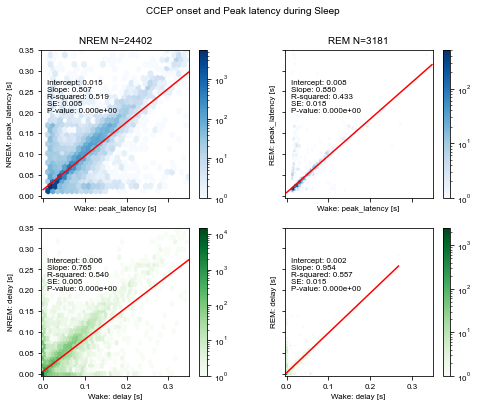

In [113]:
# data prep
# Filter DataFrame for relevant SleepStates
filtered_df = con_sleep[con_sleep['SleepState'].isin(['Wake', 'NREM', 'REM'])]

filtered_df = filtered_df[filtered_df.Num_sig_trial>10].reset_index(drop=True)
    
# Setup the figure for 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(8,6), sharex=True, sharey=True, gridspec_kw={'wspace': 0.2})
plt.suptitle('CCEP onset and Peak latency during Sleep')

for ix_state, state in enumerate(['NREM', 'REM']):
    for ix_metric, metric,cmap in zip([0,1],['peak_latency','delay'],['Blues','Greens']):
        # First, calculate the mean delay for each group
        ax = axs[ix_metric,ix_state]
        grouped = filtered_df.groupby(['Subj', 'Stim', 'Chan', 'SleepState'])[metric].mean()

        # Unstack the SleepState level, which pivots SleepState into columns
        unstacked = grouped.unstack(level='SleepState')

        # Optionally, rename the columns for clarity
        unstacked.columns = [f'delay_{state}' for state in unstacked.columns]

        # Reset the index to flatten the DataFrame
        final_df = unstacked.reset_index()

        final_df['diff'] = abs(final_df['delay_'+state]-final_df['delay_Wake'])
        final_df = final_df[~np.isnan(final_df.delay_Wake)&~np.isnan(final_df['delay_'+state])].reset_index(drop=True)
        slope, intercept, r_value, p_value, std_err = stats.linregress(final_df['delay_Wake'], final_df['delay_'+state])
        print(len(final_df))
        
        # ax = sns.regplot(x='delay_Wake', y='delay_'+state, data=final_df, ax = axs[ix_metric,ix_state],line_kws=dict(color="r"), scatter_kws={'s': 2, 'color':'black', 'alpha': 0.1})
        x = final_df['delay_Wake']
        y = final_df['delay_'+state]
        hb = ax.hexbin(x,y, cmap =cmap, bins ='log')
        cb = fig.colorbar(hb, ax=ax)
        slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)

        # Add R^2 to the plot
        # Add regression details to plot
        text_str = f'Intercept: {intercept:.3f}\nSlope: {slope:.3f}\nR-squared: {r_value**2:.3f}\nSE: {std_err:.3f}\nP-value: {p_value:.3e}'
        ax.text(0.01, 0.2, text_str, fontsize = 8)

        x_ax_reg = np.linspace(0, np.nanmax(x), 2)

        y_ax_reg = intercept + slope*x_ax_reg
        ax.plot(x_ax_reg, y_ax_reg, color = 'r')
        if ix_metric ==0:
            ax.set_title(state+ ' N='+str(len(final_df)))
            # ax.set_xlabel('')
        ax.set_xlabel('Wake: '+metric+' [s]')
        ax.set_aspect('equal')
        ax.set_ylabel(state+': '+metric+' [s]')
        
axs[0,0].set_xlim([-0.005,0.35])
axs[0,0].set_ylim([-0.005,0.35])
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\Onset_delay_sleep.svg'
plt.savefig(file, dpi = 600)

## onset cluster centers

In [74]:
def get_connections(subjs, sub_path):
    # path_export = os.path.join(sub_path,
    #                            'EvM\\Projects\\EL_experiment\Analysis\Patients\Across\BrainMapping\General\data\\')
    start = 1
    for subj in subjs:
        path_patient_analysis = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', subj)
        summary_gen_path = path_patient_analysis + '\\' + folder + '\\data\\CC_summ_similarity.csv'  # summary_general

        con_summary_all = pd.read_csv(summary_gen_path)
        con_summary_all = con_summary_all.drop_duplicates()
        con_summary_all['Subj'] = subj
        if start:
            con_all = con_summary_all
            start = 0
        else:
            con_all = pd.concat([con_all, con_summary_all]).reset_index(drop=True)
    return con_all

In [75]:
CC_all = get_connections(subjs, sub_path)

In [76]:
CC_all = CC_all.merge(con_all[['Subj', 'Stim', 'Chan', 'Con_ID']], on=['Subj', 'Stim', 'Chan'])

In [77]:
CC_all = CC_all[~np.isnan(CC_all.onset)&~np.isnan(CC_all.peak_latency)].reset_index(drop=True)
filtered_df = CC_all.groupby('Con_ID').filter(lambda x: len(x) == 2)
N_CC = len(np.unique(filtered_df.Con_ID))

In [101]:
CC_all

,Subj,Stim,Chan,CC,LL_WOI,t_WOI,LL_pk,p_val,sig_w,d,delay,peak_latency,sig,onset,true_peak,Con_ID
0,EL010,6.0,0.0,1.0,1.190380,0.004,1.190970,1.0000,1.0,21.00,NaN,0.168,1,0.066,1.0,60
1,EL010,6.0,0.0,2.0,1.465790,0.004,1.467709,1.0000,1.0,21.00,NaN,0.156,1,0.070,1.0,60
2,EL010,7.0,0.0,1.0,1.306868,0.012,1.307169,1.0000,1.0,24.50,NaN,0.066,1,0.016,1.0,99
3,EL010,7.0,0.0,2.0,1.067222,0.012,1.076200,1.0000,1.0,24.50,NaN,0.064,1,0.014,1.0,99
4,EL010,18.0,0.0,2.0,0.618878,0.000,0.618878,0.9925,1.0,70.34,NaN,0.126,1,0.036,1.0,164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40386,EL028,80.0,89.0,1.0,1.178898,0.000,1.178898,1.0000,1.0,35.27,NaN,0.220,1,0.044,1.0,44634
40387,EL028,80.0,89.0,2.0,1.014534,0.000,1.014534,1.0000,1.0,35.27,NaN,0.088,1,0.042,1.0,44634
40388,EL028,82.0,89.0,1.0,1.229625,0.000,1.229625,1.0000,1.0,41.83,NaN,0.040,1,0.000,1.0,44770
40389,EL028,82.0,89.0,2.0,0.871180,0.000,0.897462,1.0000,1.0,41.83,NaN,0.198,1,0.000,1.0,44770


In [106]:
CC_all = CC_all[~np.isnan(CC_all.onset)&~np.isnan(CC_all.peak_latency)&(CC_all.true_peak==1)&(CC_all.peak_latency<0.35)].reset_index(drop=True)
filtered_df = CC_all.groupby('Con_ID').filter(lambda x: len(x) == 2)

In [79]:
from sklearn.metrics import mean_squared_error, median_absolute_error

C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\ipykernel_launcher.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


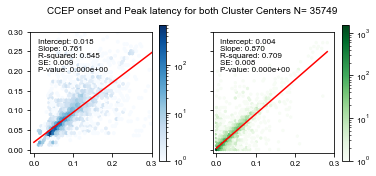

In [112]:
# Setup the figure for 2x2 subplots
fig, axs = plt.subplots(1, 2, figsize=(6, 2.5), sharex=True, sharey=True, gridspec_kw={'wspace': 0.2})
plt.suptitle('CCEP onset and Peak latency for both Cluster Centers N= '+str(N_CC))
for ix_metric, metric,cmap, gs in zip([0,1],['peak_latency','onset'],['Blues','Greens'],[50,50]):
    pivot_df = filtered_df.pivot(index='Con_ID', columns='CC', values=metric)
    pivot_df = pivot_df[~np.isnan(pivot_df[1].values)&~np.isnan(pivot_df[2].values)].reset_index(drop=True)
        
    ax = axs[ix_metric]
    x = pivot_df[1].values
    y = pivot_df[2].values
    ax.set_aspect('equal')
    hb = ax.hexbin(x,y, gridsize = gs,cmap =cmap, bins ='log')
    #ax.scatter(x,y)
    cb = fig.colorbar(hb, ax=ax)
    slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)

    # Add R^2 to the plot
    # Add regression details to plot
    text_str = f'Intercept: {intercept:.3f}\nSlope: {slope:.3f}\nR-squared: {r_value**2:.3f}\nSE: {std_err:.3f}\nP-value: {p_value:.3e}'
    ax.text(0.01, 0.2, text_str, fontsize = 8)

    x_ax_reg = np.linspace(0, np.nanmax(x), 2)

    y_ax_reg = intercept + slope*x_ax_reg
    ax.plot(x_ax_reg, y_ax_reg, color = 'r')
axs[ix_metric].set_xlim([-0.01, 0.3])
axs[ix_metric].set_ylim([-0.01, 0.3])
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\onset_CC.svg'
plt.tight_layout()
plt.savefig(file)
plt.show()

4.0 1.9999999999999982 12.0
10.000000000000002 2.0000000000000018 60.0


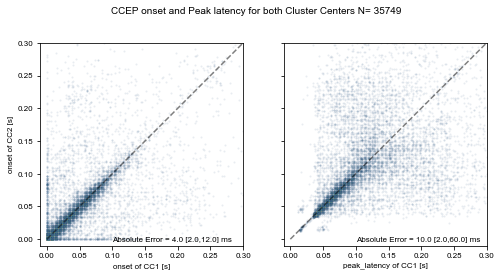

In [80]:
# Setup the figure for 2x2 subplots
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True, gridspec_kw={'wspace': 0.2})
plt.suptitle('CCEP onset and Peak latency for both Cluster Centers N= '+str(N_CC))
for ix_metric, metric in enumerate(['onset', 'peak_latency']):
    pivot_df = filtered_df.pivot(index='Con_ID', columns='CC', values=metric)
    X = pivot_df[1].values
    Y = pivot_df[2].values
    ax = sns.scatterplot(x=pivot_df[1], y=pivot_df[2], ax = axs[ix_metric], s =  4, color = color_elab[0], alpha = 0.1)
    ax.set_aspect('equal')
    #axs[ix_metric].scatter(X,Y, s= 1, alpha =0.1, color ='k')
    axs[ix_metric].plot([0, 1], [0, 1], ls ='--',alpha =0.5, color='k')
    Y_pred = X
    axs[ix_metric].set_ylabel(metric+' of CC2 [s]')
    axs[ix_metric].set_xlabel(metric+' of CC1 [s]')
    # Calculate MSE, RMSE, and MAE
    mse = mean_squared_error(Y, X)
    rmse = np.sqrt(mse)
    mae = median_absolute_error(Y, X)
    print(np.quantile(abs(X-Y)*1000, 0.5), np.quantile(abs(X-Y)*1000, 0.25), np.quantile(abs(X-Y)*1000, 0.75))
    slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)
    ax.text(0.10, 0.005, s= f'Absolute Error = {np.quantile(abs(X-Y)*1000, 0.5):.1f} [{np.quantile(abs(X-Y)*1000, 0.25):.1f},{np.quantile(abs(X-Y)*1000, 0.75):.1f}] ms', 
                     fontsize=8, verticalalignment='top')
axs[ix_metric].set_xlim([-0.01, 0.3])
axs[ix_metric].set_ylim([-0.01, 0.3])
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\onset_CC.png'
plt.savefig(file, dpi = 600)
plt.show()